In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Configuração estética
sns.set_theme(style="whitegrid")

# Gerando dados aleatórios com sementes fixas para reprodutibilidade
np.random.seed(42)

# Dados com Assimetria à Direita (Ex: Salário - maioria ganha pouco, poucos ganham muito)
# Usando distribuição Gama para simular isso
salarios = np.random.gamma(shape=2, scale=10000, size=1000) + 20000

# Dados com Distribuição Normal (Ex: Notas de 0 a 100)
notas = np.random.normal(loc=70, scale=10, size=1000)
notas = np.clip(notas, 0, 100) # Garantindo que fiquem entre 0 e 100

# Criando o DataFrame
df = pd.DataFrame({
    'Salario_Anual': salarios,
    'Nota_Desempenho': notas
})

# Visualizando as primeiras linhas
print(df.head())

   Salario_Anual  Nota_Desempenho
0   43936.793899        55.936825
1   34944.647302        69.168944
2   33822.835844        54.952796
3   33823.022943        77.600560
4   66497.144122        70.824398


In [7]:
# Medidas de Tendência Central

# Média
media_salario = df['Salario_Anual'].mean()
media_nota = df['Nota_Desempenho'].mean()

# Mediana
mediana_salario = df['Salario_Anual'].median()

# Moda
# O método .mode() retorna uma Series (pode haver mais de uma moda/bimodal)
moda_nota = df['Nota_Desempenho'].round(0).mode()[0]

print("Salários:")

print(f"Média:   R$ {media_salario:.2f}")
print(f"Mediana: R$ {mediana_salario:.2f}")
print(f"Diferença: R$ {media_salario - mediana_salario:.2f} (A média é puxada pelos salários altos)")

print(f"\nNotas:")
print(f"Média: {media_nota:.2f}")
print(f"Moda (arredondada): {moda_nota}")

# Note que no salário, a Média é significativamente maior que a Mediana. Isso indica que existem "super salários" puxando a média para cima.

Salários:
Média:   R$ 40599.30
Mediana: R$ 37290.64
Diferença: R$ 3308.66 (A média é puxada pelos salários altos)

Notas:
Média: 70.14
Moda (arredondada): 68.0


In [8]:
# Medidas de Dispersão (Variabilidade)
coluna_analise = 'Salario_Anual'

# Amplitude (Range)
amplitude = df[coluna_analise].max() - df[coluna_analise].min()

# Variância e Desvio Padrão
# ddof = 1 significa "Graus de Liberdade = 1", usado para amostras (padrão no Pandas)
variancia = df[coluna_analise].var(ddof=1)
desvio_padrao = df[coluna_analise].std(ddof=1)

# Quantis e IQR
q1 = df[coluna_analise].quantile(0.25) # 25%
q3 = df[coluna_analise].quantile(0.75) # 75%
iqr = q3 - q1

print(f"Análise de Dispersão para {coluna_analise}:")
print(f"Amplitude:      R$ {amplitude:,.2f}")
print(f"Desvio Padrão:  R$ {desvio_padrao:,.2f}")
print(f"Q1 (25%):       R$ {q1:,.2f}")
print(f"Q3 (75%):       R$ {q3:,.2f}")
print(f"IQR (Q3 - Q1):  R$ {iqr:,.2f}")

Análise de Dispersão para Salario_Anual:
Amplitude:      R$ 77,409.71
Desvio Padrão:  R$ 14,028.57
Q1 (25%):       R$ 30,262.11
Q3 (75%):       R$ 47,421.58
IQR (Q3 - Q1):  R$ 17,159.46


In [9]:
# Medidas de Forma

'''
Assimetria (Skewness):

    = 0: Simétrica (Curva Normal perfeita).

    > 0: Assimetria Positiva (Cauda longa à direita). Média > Mediana.

    < 0: Assimetria Negativa (Cauda longa à esquerda). Média < Mediana.

Curtose (Kurtosis):

    Mede o "achatamento" e a presença de caudas pesadas (outliers).

    Referência (Fisher): Normal = 0.

    > 0: Leptocúrtica (Pico alto, caudas pesadas).

    < 0: Platicúrtica (Achatada, caudas leves).
'''
skew_salario = df['Salario_Anual'].skew()
kurt_salario = df['Salario_Anual'].kurtosis()

print(f"Assimetria (Skewness): {skew_salario:.4f}")
if skew_salario > 1:
    print("-> Distribuição altamente assimétrica à direita (positiva).")

print(f"Curtose (Kurtosis):    {kurt_salario:.4f}")
if kurt_salario > 0:
    print("-> Distribuição Leptocúrtica (mais pontiaguda que a normal).")

Assimetria (Skewness): 1.1981
-> Distribuição altamente assimétrica à direita (positiva).
Curtose (Kurtosis):    1.4434
-> Distribuição Leptocúrtica (mais pontiaguda que a normal).


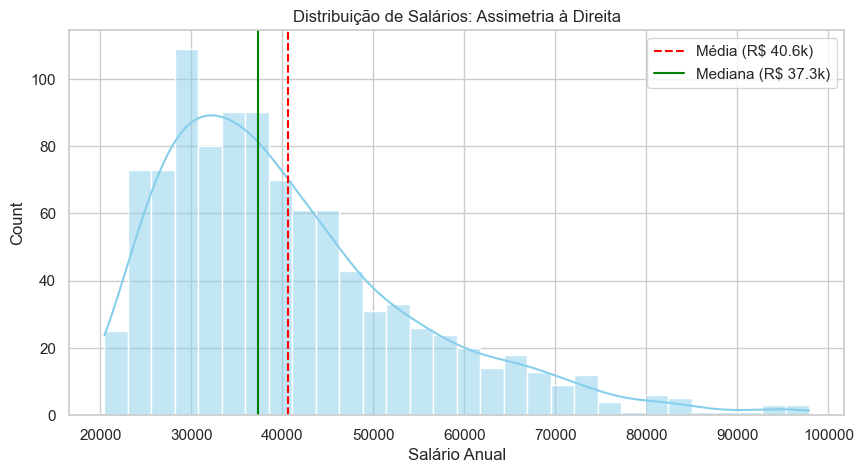

In [10]:
# Visualização Exploratória

# Histograma com KDE (Kernel Density Estimate)
# Para ver a forma da distribuição e confirmar a assimetria calculada acima.
plt.figure(figsize=(10, 5))

# Histograma com linha de densidade
sns.histplot(data=df, x='Salario_Anual', kde=True, color='skyblue', bins=30)

# Adicionando linhas verticais para Média e Mediana
plt.axvline(media_salario, color='red', linestyle='--', label=f'Média (R$ {media_salario/1000:.1f}k)')
plt.axvline(mediana_salario, color='green', linestyle='-', label=f'Mediana (R$ {mediana_salario/1000:.1f}k)')

plt.title('Distribuição de Salários: Assimetria à Direita')
plt.xlabel('Salário Anual')
plt.legend()
plt.show()

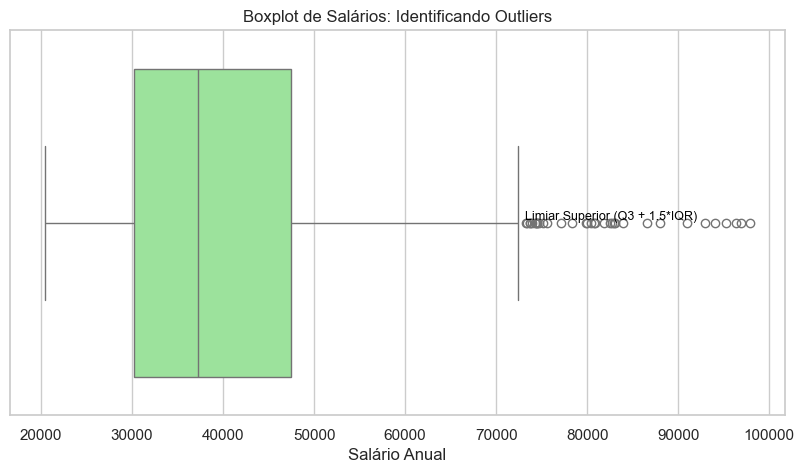

In [11]:
# Boxplot (O Caçador de Outliers)
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Salario_Anual'], color='lightgreen')

plt.title('Boxplot de Salários: Identificando Outliers')
plt.xlabel('Salário Anual')

# Anotação explicativa (opcional, bom para portfólio)
plt.text(x=q3 + 1.5*iqr, y=0, s='Limiar Superior (Q3 + 1.5*IQR)',
         verticalalignment='bottom', color='black', fontsize=9)

plt.show()

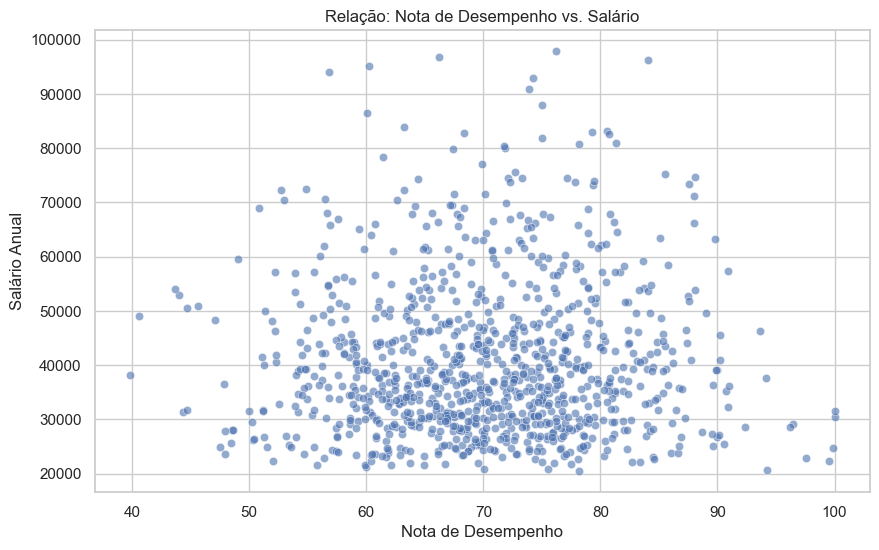

In [12]:
# Gráfico de Dispersão (Scatterplot)
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Nota_Desempenho', y='Salario_Anual', alpha=0.6)

plt.title('Relação: Nota de Desempenho vs. Salário')
plt.xlabel('Nota de Desempenho')
plt.ylabel('Salário Anual')
plt.show()

In [13]:
# O método describe nos dá: contagem, média, desvio padrão, min, quartis e max.
resumo_estatistico = df.describe()

# Adicionando Skew e Kurtosis manualmente ao resumo, pois o describe() não traz por padrão
resumo_estatistico.loc['skew'] = df.skew()
resumo_estatistico.loc['kurt'] = df.kurtosis()

print(resumo_estatistico)

       Salario_Anual  Nota_Desempenho
count    1000.000000      1000.000000
mean    40599.302661        70.135723
std     14028.570991         9.696564
min     20459.189761        39.804878
25%     30262.113287        63.573280
50%     37290.639987        70.106681
75%     47421.576815        76.660213
max     97868.904265       100.000000
skew        1.198076        -0.004906
kurt        1.443428         0.035662
